# 30 — Late Fusion (Decision-Level)

Combines the **Text**, **Audio**, and **Face** unimodal classifiers by
averaging their softmax probability vectors at utterance level.

Two strategies are evaluated:
- **Average Ensemble** — equal weights (1/3 each)
- **Weighted Ensemble** — weights found via grid search on the dev set

## Combo selection
Set `COMBO` below to run either the **heavy** or the **light** model combination:

| `COMBO` | Text | Audio | Face |
|---------|------|-------|------|
| `"heavy"` | `bert-base-uncased` | `facebook/wav2vec2-base` | `vit_b_16` |
| `"light"` | `distilbert-base-uncased` | `ntu-spml/distilhubert` | `mobilenet_v3_small` |

Results are saved to `../experiments/fusion/late/<version>/<combo>/`.

**Prerequisites:** run notebooks 10, 11, 12 (training) and 20, 21, 22 (evaluation).

In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from src.config import (
    DEVICE, VERSION,
    TRAIN_CSV, DEV_CSV, TEST_CSV,
    AUDIO_TRAIN_DIR, AUDIO_DEV_DIR, AUDIO_TEST_DIR,
    EXP_ROOT, EXP_ROOT_AUDIO, EXP_ROOT_FACE,
)
from src.data.text_preprocessing import load_split, build_label_map
from src.data.audio_preprocessing import load_audio_split
from src.data.face_dataset import load_face_metadata
from src.training.utils import slugify, write_json
from src.evaluation.late_fusion import (
    run_late_fusion,
    get_text_utterance_probs,
    get_audio_utterance_probs,
    get_face_utterance_probs,
    fuse_probs,
    score_fusion,
    grid_search_weights,
    _CANON_I2L,
)

# ──────────────────────────────────────────────────────────────────────────────
# COMBO SELECTION — set to "heavy" or "light"
# ──────────────────────────────────────────────────────────────────────────────
COMBO = "light"   # <-- change to "light" and re-run for the lightweight models
 
COMBO_MODELS = {
    "heavy": {
        "text":  "bert-base-uncased",
        "audio": "facebook/wav2vec2-base",
        "face":  "vit_b_16",
    },
    "light": {
        "text":  "distilbert-base-uncased",
        "audio": "ntu-spml/distilhubert",
        "face":  "mobilenet_v3_small",
    },
}

selected = COMBO_MODELS[COMBO]
print(f'Combo : {COMBO}')
print(f'Text  : {selected["text"]}')
print(f'Audio : {selected["audio"]}')
print(f'Face  : {selected["face"]}')
print(f'Device: {DEVICE}')

Combo : light
Text  : distilbert-base-uncased
Audio : ntu-spml/distilhubert
Face  : mobilenet_v3_small
Device: cuda


## 1 — Load data splits

In [11]:
# Text label map (alphabetical lowercase — matches audio training order)
train_text_df = load_split(TRAIN_CSV)
label2id, id2label = build_label_map(train_text_df)
print('Label map:', label2id)

# Text dev / test DataFrames (only used for ground-truth labels in fusion)
dev_text_df  = load_split(DEV_CSV,  label2id=label2id)
test_text_df = load_split(TEST_CSV, label2id=label2id)

# Audio dev / test DataFrames
dev_audio_df  = load_audio_split(DEV_CSV,  AUDIO_DEV_DIR,  label2id=label2id)
test_audio_df = load_audio_split(TEST_CSV, AUDIO_TEST_DIR, label2id=label2id)

# Face dev / test DataFrames
dev_face_df  = load_face_metadata('dev')
test_face_df = load_face_metadata('test')

print(f'Test  — text: {len(test_text_df)}, audio: {len(test_audio_df)}, face frames: {len(test_face_df)}')
print(f'Dev   — text: {len(dev_text_df)},  audio: {len(dev_audio_df)},  face frames: {len(dev_face_df)}')

Label map: {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}
Test  — text: 2610, audio: 2610, face frames: 12117
Dev   — text: 1109,  audio: 1108,  face frames: 5324


## 2 — Resolve run directories for selected combo

In [12]:
def resolve_run_dir(exp_root, model_name):
    """Return the experiment directory for a specific model, checking it exists."""
    d = os.path.join(exp_root, VERSION, slugify(model_name))
    metrics_path = os.path.join(d, 'eval_metrics.json')
    if not os.path.exists(metrics_path):
        # Face models have train_metrics only — still valid for fusion
        train_path = os.path.join(d, 'train_metrics.json')
        if not os.path.exists(train_path):
            raise FileNotFoundError(f'No metrics found in {d!r}. Run training first.')
        f1 = json.load(open(train_path)).get('best_dev_macro_f1', '?')
        print(f'  {model_name:40s}  best_dev_macro_f1={f1}')
    else:
        f1 = json.load(open(metrics_path)).get('macro_f1', '?')
        print(f'  {model_name:40s}  test_macro_f1={f1}')
    return d

print(f'=== {COMBO.upper()} combo ===')
text_run_dir  = resolve_run_dir(EXP_ROOT,       selected['text'])
audio_run_dir = resolve_run_dir(EXP_ROOT_AUDIO, selected['audio'])
face_run_dir  = resolve_run_dir(EXP_ROOT_FACE,  selected['face'])

print()
print('Text  :', text_run_dir)
print('Audio :', audio_run_dir)
print('Face  :', face_run_dir)

=== LIGHT combo ===
  distilbert-base-uncased                   test_macro_f1=0.41227390896790744
  ntu-spml/distilhubert                     test_macro_f1=0.22261778315512873
  mobilenet_v3_small                        test_macro_f1=0.182575

Text  : ../experiments/text_unimodal\v1\distilbert_base_uncased
Audio : ../experiments/audio_unimodal\v1\ntu_spml_distilhubert
Face  : ../experiments/face_unimodal\v1\mobilenet_v3_small


## 3 — Run Late Fusion

This single call:
1. Runs inference for all three modalities on both dev and test sets.
2. Grid-searches the best weights on the dev set.
3. Evaluates average and weighted ensemble on the test set.
4. Saves all artefacts to the output directory.

In [13]:
OUTPUT_DIR = f'../experiments/fusion/late/{VERSION}/{COMBO}'
print(f'Output → {OUTPUT_DIR}')

results = run_late_fusion(
    text_run_dir  = text_run_dir,
    audio_run_dir = audio_run_dir,
    face_run_dir  = face_run_dir,

    test_csv_path = TEST_CSV,
    test_audio_df = test_audio_df,
    test_face_df  = test_face_df,

    dev_csv_path  = DEV_CSV,
    dev_audio_df  = dev_audio_df,
    dev_face_df   = dev_face_df,

    do_grid_search = True,   # set False to skip grid search and use equal weights
    output_dir     = OUTPUT_DIR,
    device         = DEVICE,
)

Output → ../experiments/fusion/late/v1/light
  Late Fusion — test-set inference

[1/3] Text …


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 925.06it/s, Materializing param=pre_classifier.weight]                                  


      2610 utterances
[2/3] Audio …


Loading weights: 100%|██████████| 53/53 [00:00<00:00, 884.69it/s, Materializing param=projector.weight]                                                    


      2610 utterances
[3/3] Face …
      2481 utterances

── Average Ensemble (equal weights) ─────────────────────
  Average Ensemble (test)
  Utterances  : 2481
  Accuracy    : 0.6002
  Macro F1    : 0.4067
  Weighted F1 : 0.5847

── Grid Search on dev set ───────────────────────────────
  Dev-set inference …


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 966.76it/s, Materializing param=pre_classifier.weight]                                  


  Grid search — best dev macro-F1 : 0.4600
               best weights       : {'text': 0.4, 'audio': 0.3, 'face': 0.3}

── Weighted Ensemble  weights={text:0.40, audio:0.30, face:0.30} ──────────
  Weighted Ensemble (test)
  Utterances  : 2481
  Accuracy    : 0.5994
  Macro F1    : 0.4155
  Weighted F1 : 0.5897

Artefacts saved to  ../experiments/fusion/late/v1/light


## 4 — Results summary

In [14]:
avg = results['average_ensemble']
wt  = results['weighted_ensemble']
w   = results['weights']

summary = pd.DataFrame([
    {'combo': COMBO,
     'strategy': 'Average Ensemble (equal)',
     'weights': '{text:0.33, audio:0.33, face:0.33}',
     'accuracy': avg['accuracy'],
     'macro_f1': avg['macro_f1'],
     'weighted_f1': avg['weighted_f1'],
     'num_utterances': avg['num_utterances']},
    {'combo': COMBO,
     'strategy': 'Weighted Ensemble (grid search)',
     'weights': str(w),
     'accuracy': wt['accuracy'],
     'macro_f1': wt['macro_f1'],
     'weighted_f1': wt['weighted_f1'],
     'num_utterances': wt['num_utterances']},
])
print(summary.to_string(index=False))

combo                        strategy                                  weights  accuracy  macro_f1  weighted_f1  num_utterances
light        Average Ensemble (equal)       {text:0.33, audio:0.33, face:0.33}  0.600161  0.406746     0.584664            2481
light Weighted Ensemble (grid search) {'text': 0.4, 'audio': 0.3, 'face': 0.3}  0.599355  0.415510     0.589748            2481


## 5 — Per-class breakdown (weighted ensemble)

In [15]:
report = wt['report']
rows = []
for cls in ['Anger','Disgust','Fear','Happiness','Neutral','Sadness','Surprise']:
    if cls in report:
        r = report[cls]
        rows.append({'class': cls,
                     'precision': round(r['precision'], 4),
                     'recall':    round(r['recall'],    4),
                     'f1-score':  round(r['f1-score'],  4),
                     'support':   int(r['support'])})
pd.DataFrame(rows)

,class,precision,recall,f1-score,support
0,Anger,0.4179,0.3415,0.3758,328
1,Disgust,0.4583,0.1667,0.2444,66
2,Fear,0.1250,0.1224,0.1237,49
3,Happiness,0.5485,0.5964,0.5714,389
4,Neutral,0.7307,0.7725,0.7510,1191
5,Sadness,0.3630,0.2775,0.3145,191
6,Surprise,0.4888,0.5730,0.5276,267


## 6 — Confusion matrices

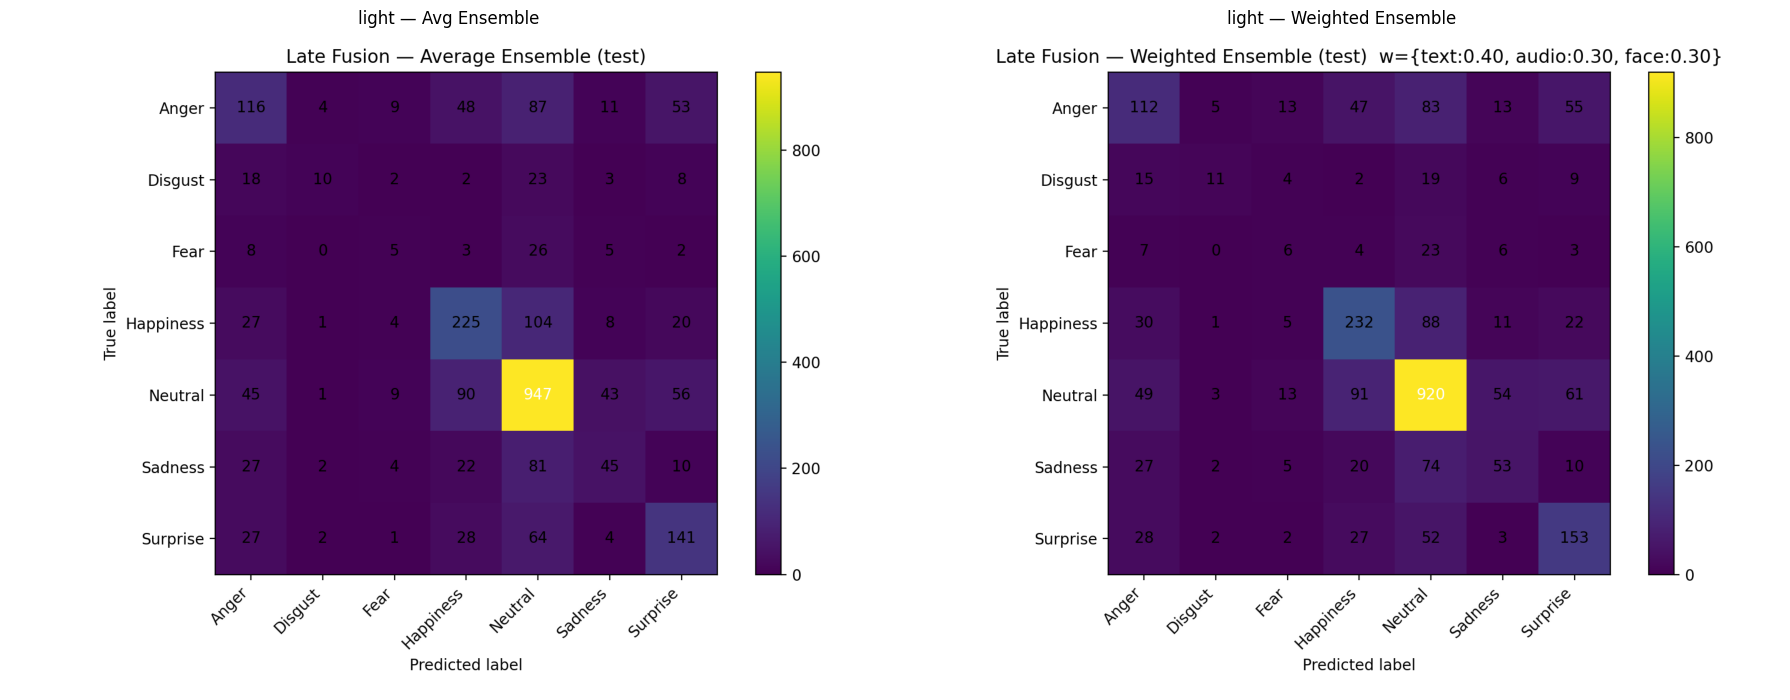

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, name in zip(axes, ['avg_ensemble', 'weighted_ensemble']):
    img_path = os.path.join(OUTPUT_DIR, f'{name}_cm.png')
    if os.path.exists(img_path):
        ax.imshow(mpimg.imread(img_path))
    ax.axis('off')
    ax.set_title(f'{COMBO} — {name.replace("_", " ").title()}')
plt.tight_layout()
plt.show()

## 7 — Manual weight exploration (optional)

Try custom weight combinations without rerunning all inference.

In [17]:
# Example: heavily favour text
custom_weights = {'text': 0.6, 'audio': 0.2, 'face': 0.2}
print('Custom weights:', custom_weights)
print('(Re-run inference cells above and call fuse_probs / score_fusion directly)')

Custom weights: {'text': 0.6, 'audio': 0.2, 'face': 0.2}
(Re-run inference cells above and call fuse_probs / score_fusion directly)
